In [197]:
import pr3_utils
import numpy as np
import sys
import scipy.sparse as sp
np.set_printoptions(threshold=sys.maxsize)
import matplotlib.pyplot as plt
import cv2 as cv

In [366]:
dataset = "02"
v_t, w_t, timestamps, features, K_l, K_r, extL_T_imu, extR_T_imu = pr3_utils.load_data("../data/dataset" + dataset + "/dataset" + dataset + ".npy")
reduced_features = np.copy(features[:, ::5, :])
if dataset == "02":
    imgs = np.load("../data/dataset" + dataset + "/dataset" + dataset + "_imgs.npy", allow_pickle=True).item()
    cam_imgs_L = np.array(imgs['cam_imgs_L'])
    cam_imgs_R = np.array(imgs['cam_imgs_R'])

# part 1: EKF prediction step

In [367]:
# calculate dleta_t, twist, pose
generalized_velocity = np.hstack([v_t, w_t])
delta_t = np.zeros(timestamps.shape[0] - 1)
for i in range(timestamps.shape[0] - 1):
    delta_t[i] = timestamps[i+1] - timestamps[i]

twist = pr3_utils.axangle2twist(generalized_velocity)
pose = np.zeros((delta_t.shape[0], 4, 4))
for i in range(delta_t.shape[0]):
    pose[i] = pr3_utils.twist2pose(delta_t[i] * twist[i])


(<Figure size 500x500 with 1 Axes>, <Axes: xlabel='x', ylabel='y'>)

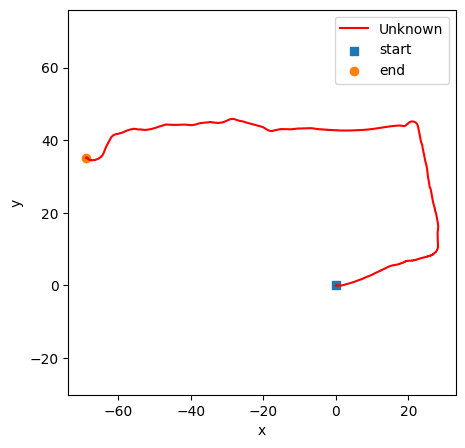

In [368]:
robot_state = np.zeros((delta_t.shape[0] + 1, 4, 4))
robot_state[0] = np.eye(4)
for i in range(delta_t.shape[0]):
    robot_state[i+1] = robot_state[i] @ pose[i]
pr3_utils.visualize_trajectory_2d(robot_state)


# Part 2: feature detection and mapping

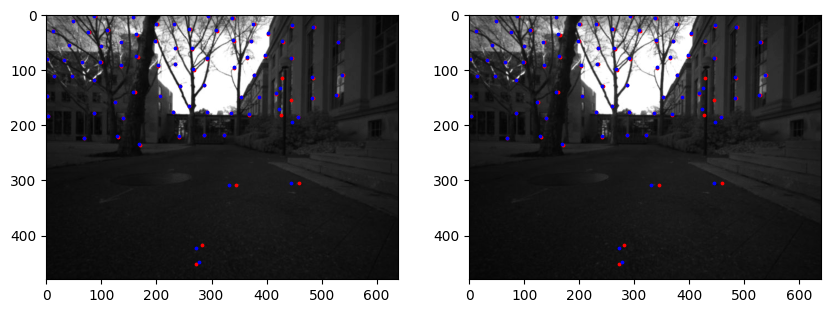

In [398]:
# apply goodFeaturesToTrack
index = 1000
img_L = cam_imgs_L[index].copy()
img_R = cam_imgs_R[index].copy()
corners_left = cv.goodFeaturesToTrack(img_L,80,0.005,30)
 
# apply calcOpticalFlowPyrLK
corners_right, status, err = cv.calcOpticalFlowPyrLK(img_L, img_R, corners_left, None)

# Iterate over the corners and draw a circle at that location
good_corners_L = corners_left[status == 1]
good_corners_R = corners_right[status == 1]
good_corners_L = good_corners_L.astype(int)
good_corners_R = good_corners_R.astype(int)

fig, axes = plt.subplots(1, 2, figsize=((10, 8)))
axes[0].imshow(img_L, cmap='gray')
axes[1].imshow(img_R, cmap='gray')
for i in good_corners_L:
    x,y = i.ravel()
    axes[0].scatter(x, y, 3, c='r')
    axes[1].scatter(x, y, 3, c='r')
for i in good_corners_R:
    x,y = i.ravel()
    axes[0].scatter(x, y, 3, c='b')
    axes[1].scatter(x, y, 3, c='b')

# Display the image
plt.show()

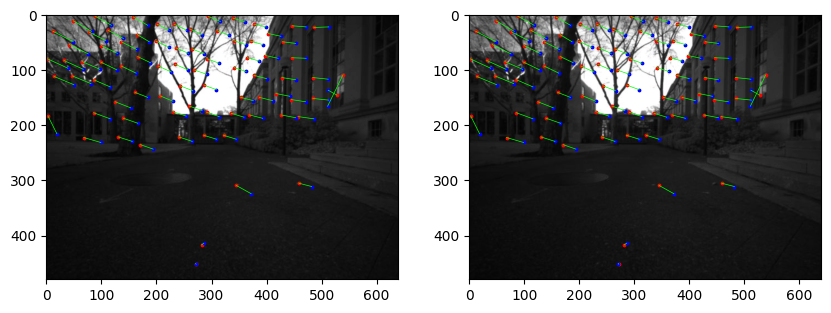

In [400]:
# apply goodFeaturesToTrack
index = 1000
img_now = cam_imgs_L[index].copy()
img_later = cam_imgs_L[index+15].copy()
corners_left = cv.goodFeaturesToTrack(img_L,80,0.005,30)
 
# apply calcOpticalFlowPyrLK
corners_right, status, err = cv.calcOpticalFlowPyrLK(img_now, img_later, corners_left, None)

# Iterate over the corners and draw a circle at that location
good_corners_L = corners_left[status == 1]
good_corners_R = corners_right[status == 1]
good_corners_L = good_corners_L.astype(int)
good_corners_R = good_corners_R.astype(int)

fig, axes = plt.subplots(1, 2, figsize=((10, 8)))
axes[0].imshow(img_L, cmap='gray')
axes[1].imshow(img_R, cmap='gray')

for i in range(good_corners_L.shape[0]):
    axes[0].plot([good_corners_L[i, 0], good_corners_R[i, 0]], [good_corners_L[i, 1], good_corners_R[i, 1]], c='lime', linestyle="-", linewidth=0.5)
    axes[1].plot([good_corners_L[i, 0], good_corners_R[i, 0]], [good_corners_L[i, 1], good_corners_R[i, 1]], c='lime', linestyle="-", linewidth=0.5)

axes[0].scatter(good_corners_L[:, 0], good_corners_L[:, 1], 3, c='r')
axes[1].scatter(good_corners_L[:, 0], good_corners_L[:, 1],3, c='r')
axes[0].scatter(good_corners_R[:, 0], good_corners_R[:, 1],3, c='b')
axes[1].scatter(good_corners_R[:, 0], good_corners_R[:, 1],3, c='b')

# Display the image
plt.show()

# Part 3: landmark mapping via EKF

In [348]:
# Calculate some camera parameters 
cl_T_cr = extL_T_imu @ pr3_utils.inversePose(extR_T_imu)
b = cl_T_cr[1, 3]
# print(b)
Ks = np.array([[1, 0, 0, 0],
               [0, 1, 0, 0],
               [1, 0, 0, -b],
               [0, 1, 0, 0]])
# print(Ks)
oTr = np.array([[0, -1, 0, 0],
                [0, 0, -1, 0],
                [1, 0, 0, 0],
                [0, 0, 0, 1]])
oTi = oTr @ extL_T_imu
# print(oTi)
inv_K_l = np.linalg.inv(K_l)
inv_K_r = np.linalg.inv(K_r)

In [349]:
# Normalized Pixel coordinate
def normalized_pixel(features, inv_K_l, inv_K_r):
    left_camera = np.ones(3)
    left_camera[0:2] = features[0:2]
    left_camera = inv_K_l @ left_camera.T
    uL, vL, _ = left_camera
    right_camera = np.ones(3)
    right_camera[0:2] = features[0:2]
    right_camera = inv_K_r @ left_camera.T
    uR, vR, _ = right_camera
    return uL, vL, uR, vR


In [350]:
for t in range(reduced_features.shape[2]):
    for i in range(reduced_features.shape[1]):
        if np.all(reduced_features[:, i, t] != -1):
            # print(reduced_features[:, i, t])
            reduced_features[:, i, t] = normalized_pixel(reduced_features[:, i, t], inv_K_l, inv_K_r)
            # print(reduced_features[:, i, t])

In [351]:
def feature2coordinate(features, b, extL_T_imu, robot_state):
    uL, vL, uR, _ = features
    coordinate = np.zeros(3)
    coordinate[2] = b / max(1, uL - uR)
    coordinate[0] = (coordinate[2] * uL)
    coordinate[1] = (coordinate[2] * vL)
    # print(coordinate)
    cRo = np.array([[0, 0, 1],
                    [-1 , 0, 0],
                    [0, -1, 0]])
    coordinate = cRo @ coordinate
    coordinate = coordinate - extL_T_imu[0:3, -1]
    coordinate = robot_state[0:3, 0:3] @ coordinate + robot_state[0:3, -1]

    return coordinate

In [240]:
# Calculate how many feature in each time stamp
featureCount = np.zeros(features.shape[2])
for i in range(features.shape[2]):
    for j in range(reduced_features.shape[1]):
        if np.all(reduced_features[:, j, i] != -1):
            featureCount[i] += 1
np.save("dataset" + str(dataset) + "_featureCount.npy", featureCount)


In [353]:
featureCount = np.load("dataset" + str(dataset) + "_featureCount.npy")
# print(featureCount)

In [354]:
def pi(input):
    # input a 4 * 1 vector, return 4 * 1 pi-projection
    # verified
    return input / input[2]

def proximateZ(Ks, oTi, pose, mu):
    # input a 3 * 1 coordinate, return 4 * 1 pixel proximate
    # verified
    mu_bar = np.zeros(4)
    mu_bar[0:3] = mu
    return Ks @ pi(oTi @ pr3_utils.inversePose(pose) @ mu_bar.T)

def dpi(input):
    # input a 4 * 1 vector, return 4 * 4 dpi/dq
    # verified
    q3 = input[2]
    dpidq = np.eye(4) / q3
    dpidq[:, 2] -= input / q3**2
    return dpidq

def mapCalH(Ks, oTi, pose, mu):
    # calculate H in EKF predict step
    # verified
    mu_bar = np.zeros(4)
    mu_bar[0:3] = mu
    P = np.array([[1, 0, 0],
                  [0, 1, 0],
                  [0, 0, 1],
                  [0, 0, 0]])
    return Ks @ dpi(oTi @ pr3_utils.inversePose(pose) @ mu_bar.T) @ oTi @ pr3_utils.inversePose(pose) @ P


In [355]:
landmark = np.zeros(3 * reduced_features.shape[1])
covariance = np.eye(3 * reduced_features.shape[1]) * 1e-4
covariance = sp.csr_matrix(covariance)
for t in range(reduced_features.shape[2]):
    if featureCount[t] == 0:
        continue
    H = np.zeros((4 * int(featureCount[t]), 3 * reduced_features.shape[1]))
    H = sp.csr_matrix(H)
    z = np.zeros(4 * int(featureCount[t]))
    z_prox = np.zeros(4 * int(featureCount[t]))
    count = 0
    for j in range(reduced_features.shape[1]):
        if np.all(reduced_features[:, j, t] != -1):
            # if not yet initial, initialize point
            if np.all(landmark[3*j: 3*j+3] == 0):
                landmark[3*j: 3*j+3] = feature2coordinate(reduced_features[:, j, t], b, extL_T_imu, robot_state[t, :, :])
            z[4*count: 4*count+4] = reduced_features[:, j, t+1]
            z_prox[4*count: 4*count+4] = proximateZ(Ks, oTi, robot_state[t+1, :, :], landmark[3*j: 3*j+3])
            H[4*count: 4*count+4, 3*j: 3*j+3] = mapCalH(Ks, oTi, robot_state[t+1, :, :], landmark[3*j: 3*j+3])
            count += 1
    K = covariance @ H.T @ np.linalg.inv(H @ covariance @ H.T + np.eye(4 * int(featureCount[t])) * 0.1)
    K = sp.csr_matrix(K)
    landmark += K @ (z-z_prox).T
    # # print(mu.shape)
    covariance = (sp.identity(3 * reduced_features.shape[1]) - K @ H) @ covariance


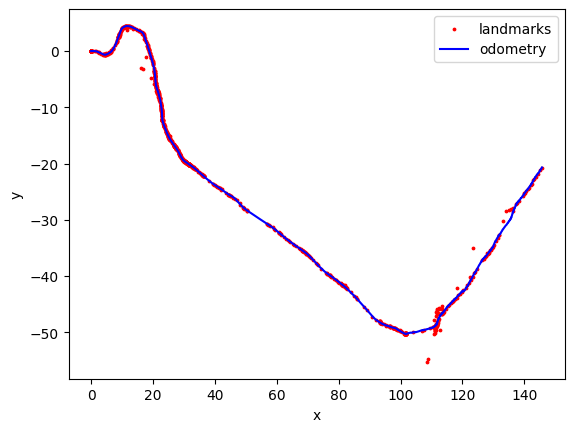

In [356]:
landmarks = landmark.reshape((-1, 3))
plt.scatter(landmarks[:, 0], landmarks[:, 1], c='r', s=3, label="landmarks")
plt.plot(robot_state[:,0,3], robot_state[:,1,3],'b-', label="odometry")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# Part 4: Visual-inertial SLAM

In [357]:
def adtwist2adpose(theta, twist):
    thetaNorm = np.linalg.norm(theta)
    adpose = np.eye(6)
    if thetaNorm == 0:
        return adpose
    twistMul = twist
    adpose += (3 * np.sin(thetaNorm) - thetaNorm * np.cos(thetaNorm)) / (2 * thetaNorm) * twistMul
    twistMul = twist @ twistMul
    adpose += (4 - thetaNorm * np.sin(thetaNorm) - 4 * np.cos(thetaNorm) / 2 * (2 * thetaNorm ** 2)) * twistMul
    twistMul = twist @ twistMul
    adpose += (np.sin(thetaNorm) - thetaNorm * np.cos(thetaNorm)) / (2 * thetaNorm ** 3) * twistMul
    twistMul = twist @ twistMul
    adpose += (2 - thetaNorm * np.sin(thetaNorm) - 2 * np.cos(thetaNorm) / 2 * (2 * thetaNorm ** 4)) * twistMul
    # return adpose
    return twist

def circleDot(s):
    circle = np.zeros((4, 6))
    circle[0:3, 0:3] = np.eye(3)
    circle[0:3, 3:] = -pr3_utils.axangle2skew(s)
    return circle

def pred_step(mu, cov, deltaT, ut):
    W = np.eye(6) * np.array([0.01, 0.01, 0.01, 1e-3, 1e-3, 1e-3])
    mu_next = mu @ pr3_utils.twist2pose(deltaT * pr3_utils.axangle2twist(ut))
    cov_next = adtwist2adpose(ut[3:], -deltaT * pr3_utils.axangle2adtwist(ut)) @ cov @ adtwist2adpose(ut[3:], -deltaT * pr3_utils.axangle2adtwist(ut)).T + W
    return mu_next, cov_next

def odoCalH(Ks, oTi, pose, landmark):
    m = np.zeros(4)
    m[0:3] = landmark
    H = -Ks @ dpi(oTi @ pr3_utils.inversePose(pose) @ m.T) @ oTi @ circleDot(pr3_utils.inversePose(pose) @ m)
    return H

In [364]:
odometry = np.zeros((delta_t.shape[0] + 1, 4, 4))
odometry[0] = np.eye(4)
cov = np.zeros((6, 6))
for t in range(delta_t.shape[0]):
    # prediction step
    odometry[t+1], cov = pred_step(odometry[t], cov, delta_t[t], generalized_velocity[t])
    # update step
    count = 0
    z = np.zeros(4 * int(featureCount[t]))
    z_prox = np.zeros(4 * int(featureCount[t]))
    H = np.zeros((int(4 * featureCount[t]), 6))
    H = sp.csr_matrix(H)
    for j in range(reduced_features.shape[1]):
        if np.all(reduced_features[:, j, t] != -1):
            z[4*count: 4*count+4] = reduced_features[:, j, t+1]
            z_prox[4*count: 4*count+4] = proximateZ(Ks, oTi, robot_state[t+1, :, :], landmark[3*j: 3*j+3])
            H[4*count: 4*count+4] = odoCalH(Ks, oTi, odometry[t+1], landmark[3*j: 3*j+3])
            count += 1
    K = cov @ H.T @ np.linalg.inv(H @ cov @ H.T + np.eye(4 * int(featureCount[t])) * 7.5e3)
    K = sp.csr_matrix(K)
    odometry[t+1] = odometry[t+1] @ (pr3_utils.axangle2pose(K @ (z - z_prox).T))
    cov = (np.eye(6) - K @ H) @ cov

/Users/heziqin/Desktop/sensing and estimation/ECE276A_PR3/code/pr3_utils.py:196: RuntimeWarning: invalid value encountered in divide
  Tn = np.nan_to_num(T / rotang)
/Users/heziqin/Desktop/sensing and estimation/ECE276A_PR3/code/pr3_utils.py:196: RuntimeWarning: divide by zero encountered in divide
  Tn = np.nan_to_num(T / rotang)
/usr/local/lib/python3.11/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


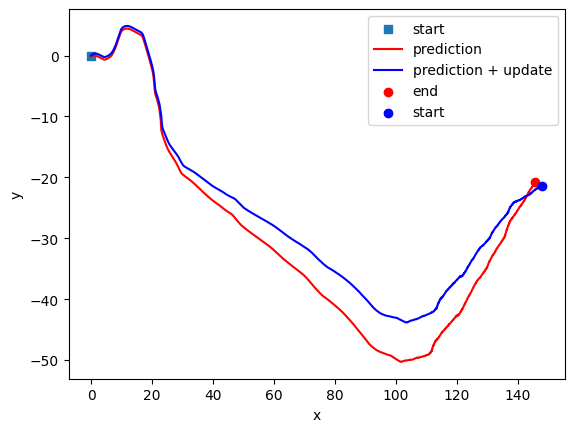

In [365]:
plt.close()
plt.scatter(robot_state[0,0,3], robot_state[0,1,3],marker='s', label="start")
plt.plot(robot_state[:,0,3], robot_state[:,1,3],'r-', label="prediction")
plt.plot(odometry[:,0,3], odometry[:,1,3], 'b-', label="prediction + update")
plt.scatter(robot_state[-1,0,3], robot_state[-1,1,3], marker='o', c='r', label="end")
plt.scatter(odometry[-1,0,3], odometry[-1,1,3], marker='o', c='b', label="start")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()